<a href="https://colab.research.google.com/github/pedraocoder/Projeto-AV2-ML1-ET0-Pernambuco/blob/main/et0_pernambuco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# PARTE 1: Carregamento dos dados e visualização inicial:

import pandas as pd
import numpy as np
import os
import zipfile

with zipfile.ZipFile('Dados_inmet_pernambuco_2023.zip', 'r') as z:
    z.extractall('dados_inmet')

def ler_estacao(filepath):
    meta = {}
    with open(filepath, encoding='latin-1') as f:
        for i, line in enumerate(f):
            if i == 0: meta['nome']      = line.split(':')[1].strip()
            if i == 1: meta['codigo']    = line.split(':')[1].strip()
            if i == 2: meta['latitude']  = float(line.split(':')[1].strip())
            if i == 3: meta['longitude'] = float(line.split(':')[1].strip())
            if i == 4: meta['altitude']  = float(line.split(':')[1].strip())
            if i == 9: break

    df = pd.read_csv(filepath, sep=';', skiprows=10,
                     encoding='latin-1', decimal='.',
                     na_values=['null', 'NULL', '', ' '])
    df.columns = ['data','pressao','tmax','tmed',
                  'tmin','ur_med','ur_min','vento','vazio']
    df = df.drop(columns=['vazio'], errors='ignore')
    df['data'] = pd.to_datetime(df['data'], errors='coerce')
    df = df.dropna(subset=['data'])
    for k, v in meta.items():
        df[k] = v
    return df

# Nota: 3 estações (Caruaru, Petrolina, Serra Talhada) tiveram falha
# de equipamento no início de 2023 e só possuem dados parciais.
# Estações com menos de 30 dias válidos são descartadas automaticamente.

todos = []
print("Carregando estações...\n")
for root, dirs, arquivos in os.walk('dados_inmet'):
    for arq in sorted(arquivos):
        if arq.endswith('.csv'):
            est = ler_estacao(os.path.join(root, arq))
            dias_validos = est['tmed'].notna().sum()
            if dias_validos >= 30:
                est = est.dropna(subset=['tmax','tmed','tmin','ur_med','vento'], how='all')
                todos.append(est)
                print(f" {est['nome'].iloc[0]:<15} {dias_validos} dias válidos")
            else:
                print(f" {est['nome'].iloc[0]:<15} sem dados — ignorada")

df = pd.concat(todos, ignore_index=True)
print(f"\n{'='*50}")
print(f"Total de estações carregadas: {df['nome'].nunique()}")
print(f"Total de registros:           {len(df)}")
print(f"Período:                      {df['data'].min().date()} a {df['data'].max().date()}")

print(f"\n--- Estações e coordenadas ---")
print(df[['nome','codigo','latitude','longitude','altitude']]
      .drop_duplicates()
      .sort_values('nome')
      .to_string(index=False))

print(f"\n--- Primeiros registros com dados válidos ---")
print(df[df['tmed'].notna()][['nome','data','tmax','tmed','tmin','ur_med','vento']]
      .head(10)
      .to_string(index=False))

print(f"\n--- Tipos das colunas ---")
print(df.dtypes)

Carregando estações...

 PETROLINA       239 dias válidos
 ARCO VERDE      334 dias válidos
 GARANHUNS       362 dias válidos
 SURUBIM         312 dias válidos
 CABROBO         365 dias válidos
 CARUARU         235 dias válidos
 IBIMIRIM        365 dias válidos
 SERRA TALHADA   305 dias válidos
 FLORESTA        365 dias válidos
 PALMARES        365 dias válidos
 OURICURI        197 dias válidos
 SALGUEIRO       333 dias válidos

Total de estações carregadas: 12
Total de registros:           3835
Período:                      2023-01-01 a 2023-12-31

--- Estações e coordenadas ---
         nome codigo  latitude  longitude  altitude
   ARCO VERDE   A309 -8.433611 -37.055556    683.95
      CABROBO   A329 -8.503889 -39.315278    342.74
      CARUARU   A341 -8.356111 -36.028333    837.00
     FLORESTA   A351 -8.598889 -38.584167    327.42
    GARANHUNS   A322 -8.910833 -36.493333    827.78
     IBIMIRIM   A349 -8.509444 -37.711667    434.23
     OURICURI   A366 -7.885833 -40.102778    457.

In [ ]:
# Inspeção dos dados

print("=== DIMENSÃO DA BASE ===")
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")

print("\n=== PRIMEIRAS LINHAS ===")
print(df[df['tmed'].notna()][['nome','data','tmax','tmed','tmin','ur_med','vento']].head(8).to_string(index=False))

print("\n=== VALORES AUSENTES POR COLUNA ===")
print(df[['tmax','tmed','tmin','ur_med','ur_min','vento','pressao']].isna().sum().to_string())

print("\n=== REGISTROS DUPLICADOS ===")
dups = df.duplicated(subset=['nome','data']).sum()
print(f"Duplicatas encontradas: {dups}")

print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
print(df[['tmax','tmed','tmin','ur_med','vento','pressao']].describe().round(2).to_string())

print("\n=== TRATAMENTO APLICADO ===")
print("1. Valores 'null' do INMET convertidos para NaN")
print("2. Linhas com todas variáveis nulas removidas")
print("3. Estações com menos de 30 dias válidos descartadas")
print("4. ET₀ negativa ou > 20 mm/dia removida (fisicamente impossível)")
print(f"5. Registros antes do tratamento: 4380 | Após: {len(df)}")

=== DIMENSÃO DA BASE ===
Linhas: 3835 | Colunas: 13

=== PRIMEIRAS LINHAS ===
     nome       data  tmax  tmed  tmin  ur_med  vento
PETROLINA 2023-05-05  32.9  28.0  24.3    61.5    3.4
PETROLINA 2023-05-06  31.5  26.8  23.7    65.9    3.2
PETROLINA 2023-05-07  33.7  27.1  23.1    63.5    3.3
PETROLINA 2023-05-08  33.5  27.5  22.7    59.3    3.1
PETROLINA 2023-05-09  34.6  27.9  23.1    60.0    3.0
PETROLINA 2023-05-10  34.4  28.4  23.4    59.7    3.3
PETROLINA 2023-05-11  34.4  28.4  23.8    57.0    2.1
PETROLINA 2023-05-12  35.7  28.4  23.8    59.4    2.4

=== VALORES AUSENTES POR COLUNA ===
tmax        12
tmed        58
tmin        12
ur_med     445
ur_min     305
vento       22
pressao     68

=== REGISTROS DUPLICADOS ===
Duplicatas encontradas: 0

=== ESTATÍSTICAS DESCRITIVAS ===
          tmax     tmed     tmin   ur_med    vento  pressao
count  3823.00  3777.00  3823.00  3390.00  3813.00  3767.00
mean     31.59    25.23    20.76    67.97     2.38   960.65
std       3.68     2.90 

In [ ]:
# PARTE 2: Cálculo da ET0 (Penman-Monteith FAO-56):

def calcular_et0(df_input):
    df = df_input.copy()
    lat_rad = np.radians(df['latitude'].iloc[0])
    altitude = df['altitude'].iloc[0]

    # Dia do ano
    df['J'] = df['data'].dt.dayofyear

    # Pressão atmosférica (kPa) — converte de mB para kPa
    df['P'] = df['pressao'].fillna(
        101.3 * ((293 - 0.0065 * altitude) / 293) ** 5.26
    ) / 10

    # Constante psicrométrica γ
    df['gama'] = 0.000665 * df['P']

    # Temperatura média
    df['Tmed'] = df['tmed'].fillna((df['tmax'] + df['tmin']) / 2)

    # Declinação solar
    df['delta_sol'] = 0.409 * np.sin(2 * np.pi * df['J'] / 365 - 1.39)

    # Ângulo horário do pôr do sol
    df['ws'] = np.arccos(-np.tan(lat_rad) * np.tan(df['delta_sol']))

    # Radiação extraterrestre Ra (MJ/m²/dia)
    dr = 1 + 0.033 * np.cos(2 * np.pi * df['J'] / 365)
    df['Ra'] = (24 * 60 / np.pi) * 0.0820 * dr * (
        df['ws'] * np.sin(lat_rad) * np.sin(df['delta_sol']) +
        np.cos(lat_rad) * np.cos(df['delta_sol']) * np.sin(df['ws'])
    )

    # Radiação solar Rs — estimada por Hargreaves (sem piranômetro)
    df['Rs'] = 0.16 * np.sqrt(df['tmax'] - df['tmin']) * df['Ra']

    # Radiação de ondas curtas líquida Rns
    df['Rns'] = 0.77 * df['Rs']

    # Pressão de vapor à saturação es (kPa)
    df['es'] = 0.6108 * np.exp(17.27 * df['Tmed'] / (df['Tmed'] + 237.3))

    # Pressão de vapor atual ea (kPa)
    df['ea'] = df['ur_med'] / 100 * df['es']

    # Radiação de ondas longas Rnl
    Tmax_K = df['tmax'] + 273.16
    Tmin_K = df['tmin'] + 273.16
    df['Rnl'] = 4.903e-9 * ((Tmax_K**4 + Tmin_K**4) / 2) * \
                (0.34 - 0.14 * np.sqrt(df['ea'])) * \
                (1.35 * df['Rs'] / (0.75 * df['Ra']) - 0.35)

    # Saldo de radiação Rn
    df['Rn'] = df['Rns'] - df['Rnl']

    # Slope da curva de pressão de vapor Δ
    df['Delta'] = 4098 * df['es'] / (df['Tmed'] + 237.3) ** 2

    # Velocidade do vento a 2m (corrigida de 10m)
    df['u2'] = df['vento'] * (4.87 / np.log(67.8 * 10 - 5.42))

    # ET₀ Penman-Monteith FAO-56 (mm/dia)
    num = (0.408 * df['Delta'] * (df['Rn'] - 0) +
           df['gama'] * (900 / (df['Tmed'] + 273)) * df['u2'] * (df['es'] - df['ea']))
    den = df['Delta'] + df['gama'] * (1 + 0.34 * df['u2'])
    df['ET0'] = num / den

    return df

resultados = []
for nome, grupo in df.groupby('nome'):
    resultados.append(calcular_et0(grupo))

df = pd.concat(resultados, ignore_index=True)

df = df[df['ET0'].notna() & (df['ET0'] > 0) & (df['ET0'] < 20)]

resumo = df.groupby('nome')['ET0'].agg(['mean','min','max','count']).round(2)
resumo.columns = ['ET0_media', 'ET0_min', 'ET0_max', 'dias']

print("ET₀ calculada com sucesso!")
print(f"Total de registros válidos: {len(df)}\n")
print("--- ET₀ média anual por estação (mm/dia) ---")
print(resumo.to_string())

ET₀ calculada com sucesso!
Total de registros válidos: 3372

--- ET₀ média anual por estação (mm/dia) ---
               ET0_media  ET0_min  ET0_max  dias
nome                                            
ARCO VERDE          4.22     1.81     6.45   334
CABROBO             3.96     2.32     5.91   365
CARUARU             3.08     1.29     5.36   236
FLORESTA            5.14     2.74     7.46   365
GARANHUNS           3.73     1.96     5.95   227
IBIMIRIM            5.45     3.64     6.61    80
OURICURI            4.53     2.48     6.93   191
PALMARES            3.49     1.36     4.83   350
PETROLINA           5.26     2.84     7.65   241
SALGUEIRO           4.70     2.48     7.68   364
SERRA TALHADA       4.62     2.39     7.31   304
SURUBIM             3.81     1.80     5.50   315


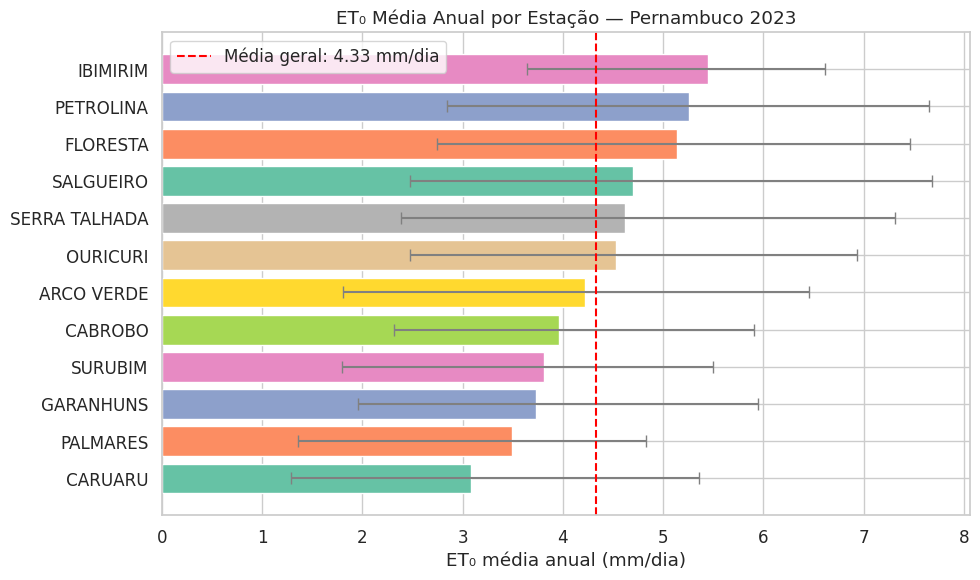

Gráfico 1: ET₀ por estação — sertão claramente mais alto que zona da mata



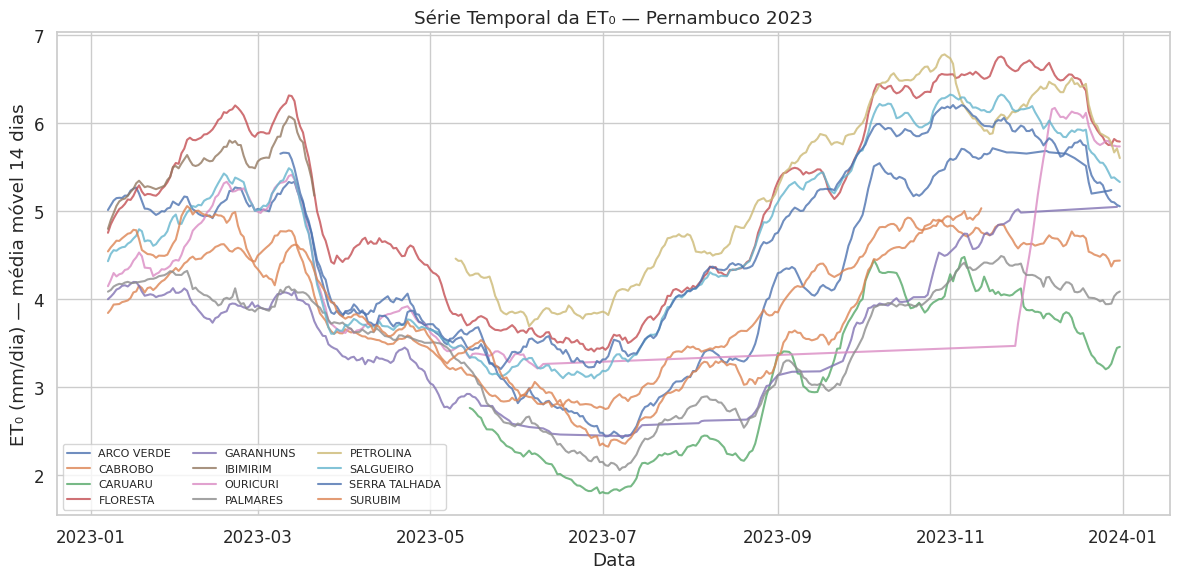

Gráfico 2: sazonalidade clara — ET₀ maior no verão/seco, menor no inverno/chuvoso



/tmp/ipykernel_4201/2435188617.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='nome', y='ET0', order=ordem,


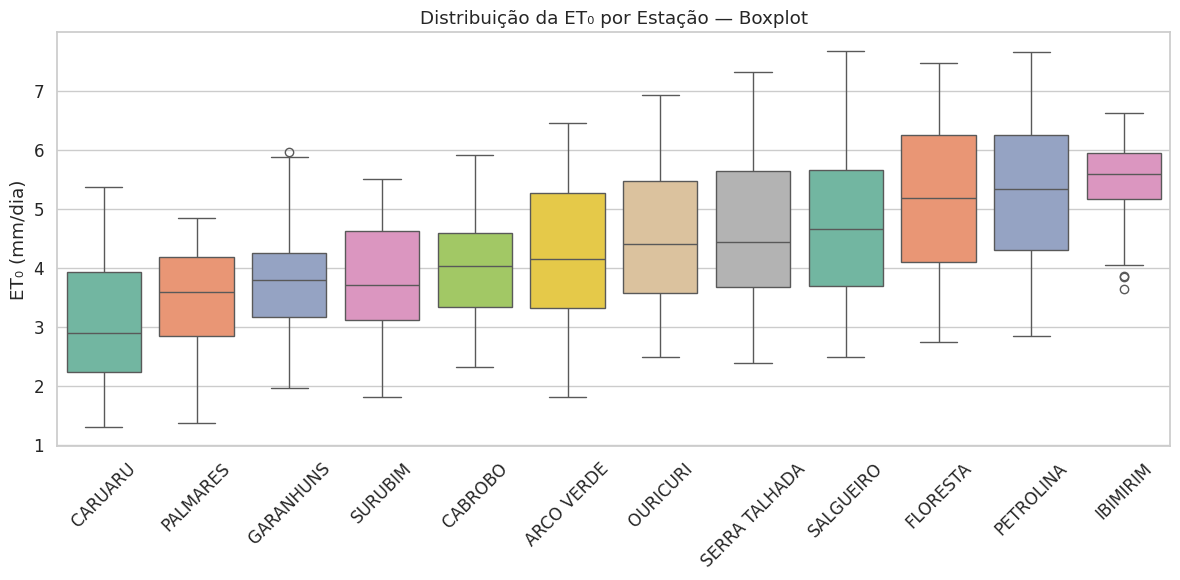

Gráfico 3: boxplot mostra dispersão e outliers por estação



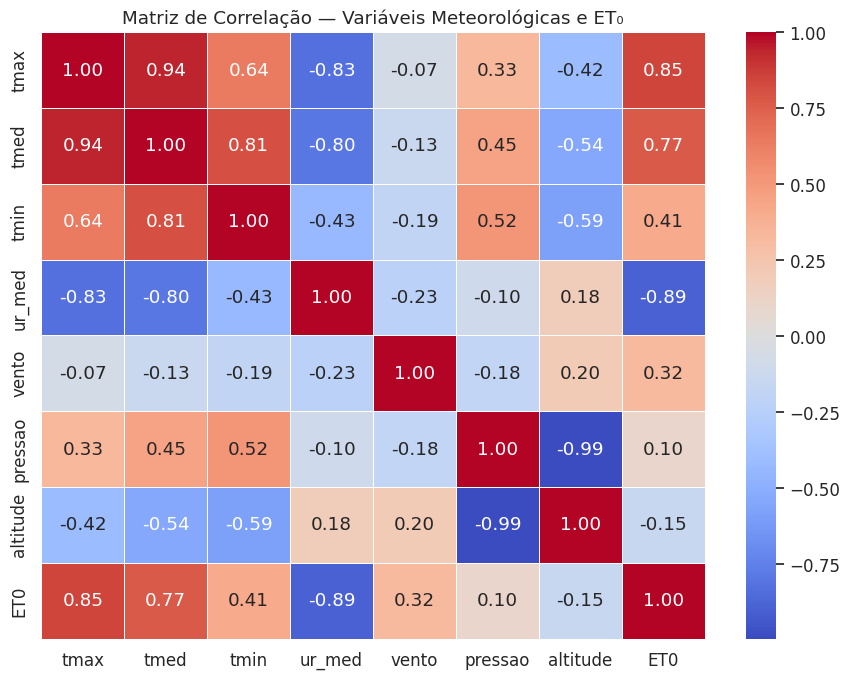

Gráfico 4: correlação mostra quais variáveis mais influenciam ET₀



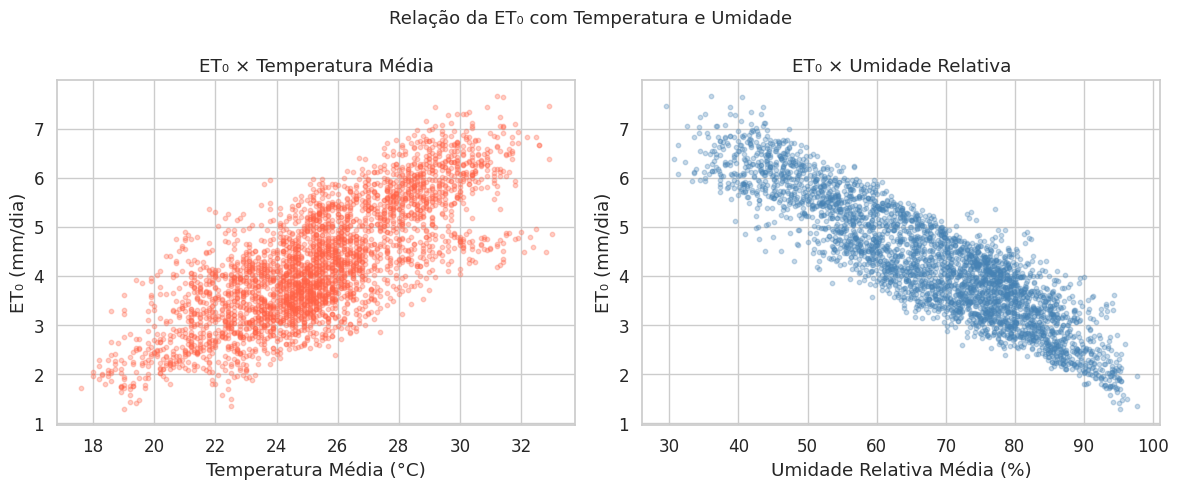

Gráfico 5: temperatura correlaciona positivamente, umidade negativamente com ET₀

✓ Todos os gráficos gerados e salvos!


In [ ]:
# PARTE 3: Visualizações — EDA

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
cores = sns.color_palette("Set2", 12)

# ── Gráfico 1: ET₀ média por estação ──────────────────────────
resumo_sorted = resumo.sort_values('ET0_media', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(resumo_sorted.index, resumo_sorted['ET0_media'],
               color=cores, edgecolor='white')
ax.errorbar(resumo_sorted['ET0_media'], resumo_sorted.index,
            xerr=[resumo_sorted['ET0_media'] - resumo_sorted['ET0_min'],
                  resumo_sorted['ET0_max'] - resumo_sorted['ET0_media']],
            fmt='none', color='gray', capsize=4)
ax.axvline(resumo_sorted['ET0_media'].mean(), color='red',
           linestyle='--', label=f"Média geral: {resumo_sorted['ET0_media'].mean():.2f} mm/dia")
ax.set_xlabel('ET₀ média anual (mm/dia)')
ax.set_title('ET₀ Média Anual por Estação — Pernambuco 2023')
ax.legend()
plt.tight_layout()
plt.savefig('grafico1_et0_por_estacao.png', dpi=150)
plt.show()
print("Gráfico 1: ET₀ por estação — sertão claramente mais alto que zona da mata\n")

# ── Gráfico 2: Série temporal da ET₀ por estação ──────────────
fig, ax = plt.subplots(figsize=(12, 6))
for i, (nome, grupo) in enumerate(df.groupby('nome')):
    grupo_sorted = grupo.sort_values('data')
    media_movel = grupo_sorted['ET0'].rolling(14, min_periods=7).mean()
    ax.plot(grupo_sorted['data'], media_movel, label=nome, alpha=0.8)
ax.set_xlabel('Data')
ax.set_ylabel('ET₀ (mm/dia) — média móvel 14 dias')
ax.set_title('Série Temporal da ET₀ — Pernambuco 2023')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.savefig('grafico2_serie_temporal.png', dpi=150)
plt.show()
print("Gráfico 2: sazonalidade clara — ET₀ maior no verão/seco, menor no inverno/chuvoso\n")

# ── Gráfico 3: Boxplot por estação (distribuição e outliers) ───
fig, ax = plt.subplots(figsize=(12, 6))
ordem = resumo.sort_values('ET0_media').index.tolist()
df_box = df[['nome','ET0']].copy()
sns.boxplot(data=df_box, x='nome', y='ET0', order=ordem,
            palette='Set2', ax=ax)
ax.set_xlabel('')
ax.set_ylabel('ET₀ (mm/dia)')
ax.set_title('Distribuição da ET₀ por Estação — Boxplot')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('grafico3_boxplot.png', dpi=150)
plt.show()
print("Gráfico 3: boxplot mostra dispersão e outliers por estação\n")

# ── Gráfico 4: Matriz de correlação ───────────────────────────
variaveis = ['tmax','tmed','tmin','ur_med','vento','pressao','altitude','ET0']
corr = df[variaveis].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlação — Variáveis Meteorológicas e ET₀')
plt.tight_layout()
plt.savefig('grafico4_correlacao.png', dpi=150)
plt.show()
print("Gráfico 4: correlação mostra quais variáveis mais influenciam ET₀\n")

# ── Gráfico 5: ET₀ vs Temperatura e Umidade ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['tmed'], df['ET0'], alpha=0.3, color='tomato', s=10)
axes[0].set_xlabel('Temperatura Média (°C)')
axes[0].set_ylabel('ET₀ (mm/dia)')
axes[0].set_title('ET₀ × Temperatura Média')

axes[1].scatter(df['ur_med'], df['ET0'], alpha=0.3, color='steelblue', s=10)
axes[1].set_xlabel('Umidade Relativa Média (%)')
axes[1].set_ylabel('ET₀ (mm/dia)')
axes[1].set_title('ET₀ × Umidade Relativa')

plt.suptitle('Relação da ET₀ com Temperatura e Umidade', fontsize=13)
plt.tight_layout()
plt.savefig('grafico5_dispersao.png', dpi=150)
plt.show()
print("Gráfico 5: temperatura correlaciona positivamente, umidade negativamente com ET₀\n")

print("✓ Todos os gráficos gerados e salvos!")

ET₀ média anual por estação:
         nome       lat        lon    alt      ET0
   ARCO VERDE -8.433611 -37.055556 683.95 4.219832
      CABROBO -8.503889 -39.315278 342.74 3.955784
      CARUARU -8.356111 -36.028333 837.00 3.083623
     FLORESTA -8.598889 -38.584167 327.42 5.136074
    GARANHUNS -8.910833 -36.493333 827.78 3.725274
     IBIMIRIM -8.509444 -37.711667 434.23 5.449229
     OURICURI -7.885833 -40.102778 457.85 4.525003
     PALMARES -8.666667 -35.568056 164.01 3.487807
    PETROLINA -9.388333 -40.523333 372.72 5.262217
    SALGUEIRO -8.058056 -39.096111 447.00 4.700526
SERRA TALHADA -7.954167 -38.295000 499.02 4.623923
      SURUBIM -7.842500 -35.790278 421.44 3.810187


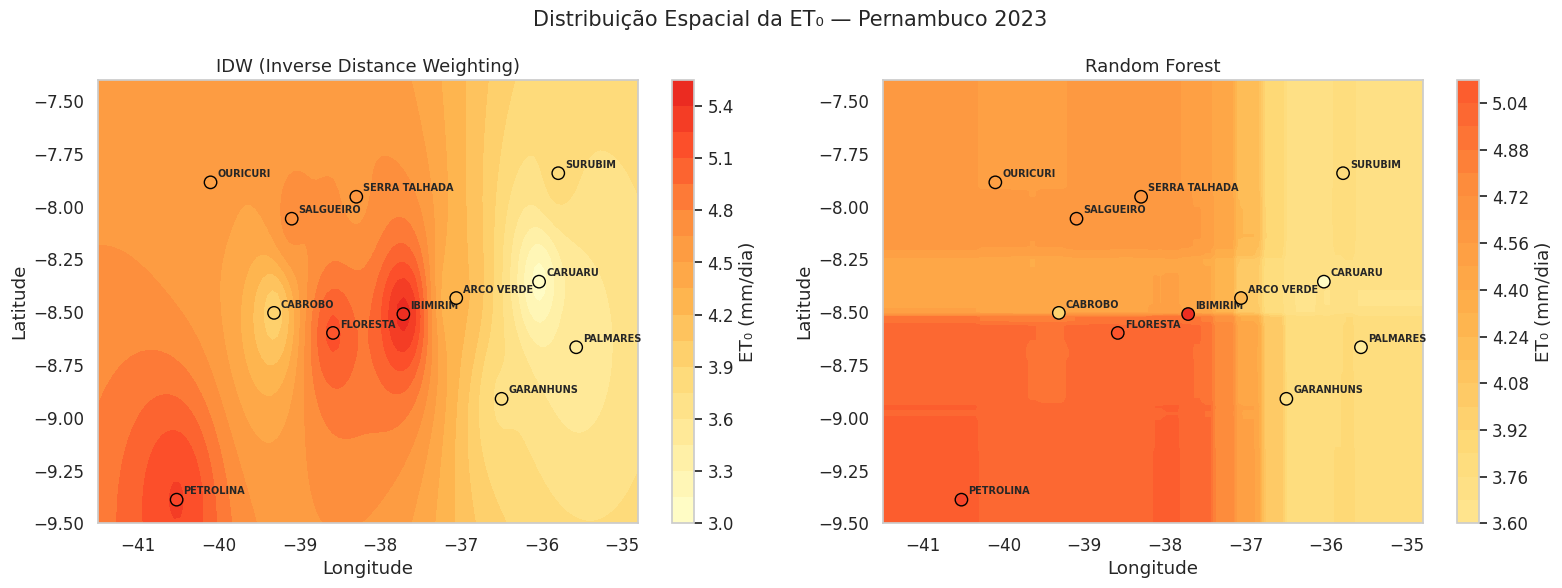

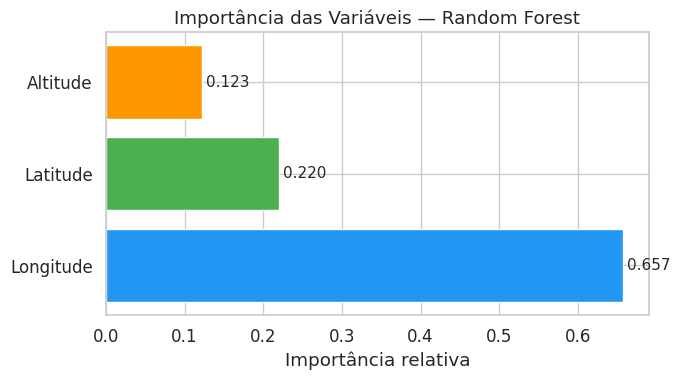


Interpolação concluída!
IDW  — ET₀ média na grade: 4.36 mm/dia
RF   — ET₀ média na grade: 4.44 mm/dia


In [ ]:
# PARTE 4: Interpolação Espacial — IDW e Random Forest

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import griddata
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# --- 4.1 Prepara dados: ET₀ média anual por estação ---
estacoes = df.groupby('nome').agg(
    lat=('latitude','first'),
    lon=('longitude','first'),
    alt=('altitude','first'),
    ET0=('ET0','mean')
).reset_index()

print("ET₀ média anual por estação:")
print(estacoes[['nome','lat','lon','alt','ET0']].to_string(index=False))

# --- 4.2 Grade de interpolação cobrindo Pernambuco ---
lat_min, lat_max = -9.5, -7.4
lon_min, lon_max = -41.5, -34.8
res = 100  # resolução da grade

grid_lon, grid_lat = np.meshgrid(
    np.linspace(lon_min, lon_max, res),
    np.linspace(lat_min, lat_max, res)
)

coords = estacoes[['lon','lat']].values
et0_vals = estacoes['ET0'].values

# --- 4.3 IDW ---
def idw(coords_known, values, coords_pred, p=2):
    results = []
    for cp in coords_pred:
        dists = np.sqrt(np.sum((coords_known - cp)**2, axis=1))
        dists = np.where(dists == 0, 1e-10, dists)
        w = 1 / dists**p
        results.append(np.sum(w * values) / np.sum(w))
    return np.array(results)

grid_points = np.column_stack([grid_lon.ravel(), grid_lat.ravel()])
et0_idw = idw(coords, et0_vals, grid_points).reshape(grid_lon.shape)

# --- 4.4 Random Forest ---
X = estacoes[['lon','lat','alt']].values
y = et0_vals

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

grid_alt = np.full(grid_lon.shape, estacoes['alt'].mean())
X_grid = np.column_stack([
    grid_lon.ravel(),
    grid_lat.ravel(),
    grid_alt.ravel()
])
et0_rf = rf.predict(X_grid).reshape(grid_lon.shape)

# --- 4.5 Plota os dois mapas lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cmap = 'YlOrRd'
vmin = 3.0
vmax = 6.5

for ax, data, titulo in zip(axes,
    [et0_idw, et0_rf],
    ['IDW (Inverse Distance Weighting)', 'Random Forest']):

    im = ax.contourf(grid_lon, grid_lat, data,
                     levels=20, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, label='ET₀ (mm/dia)')

    # Plota as estações
    sc = ax.scatter(estacoes['lon'], estacoes['lat'],
                    c=estacoes['ET0'], cmap=cmap, vmin=vmin, vmax=vmax,
                    edgecolors='black', s=80, zorder=5)
    for _, row in estacoes.iterrows():
        ax.annotate(row['nome'], (row['lon'], row['lat']),
                    textcoords='offset points', xytext=(5,4),
                    fontsize=7, fontweight='bold')

    ax.set_title(titulo, fontsize=13)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribuição Espacial da ET₀ — Pernambuco 2023', fontsize=15)
plt.tight_layout()
plt.savefig('grafico6_mapas_interpolacao.png', dpi=150)
plt.show()

# --- 4.6 Importância das variáveis (Random Forest) ---
fig, ax = plt.subplots(figsize=(7, 4))
importancias = rf.feature_importances_
variaveis_rf = ['Longitude', 'Latitude', 'Altitude']
cores_imp = ['#2196F3','#4CAF50','#FF9800']
bars = ax.barh(variaveis_rf, importancias, color=cores_imp, edgecolor='white')
ax.set_xlabel('Importância relativa')
ax.set_title('Importância das Variáveis — Random Forest')
for bar, val in zip(bars, importancias):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('grafico7_importancia_rf.png', dpi=150)
plt.show()

print("\nInterpolação concluída!")
print(f"IDW  — ET₀ média na grade: {et0_idw.mean():.2f} mm/dia")
print(f"RF   — ET₀ média na grade: {et0_rf.mean():.2f} mm/dia")

Validação Leave-One-Out:

Estação           Real    IDW     RF  Err_IDW   Err_RF
-------------------------------------------------------
ARCO VERDE        4.22   4.36   3.91     0.14     0.31
CABROBO           3.96   4.77   5.15     0.81     1.19
CARUARU           3.08   3.84   3.88     0.76     0.80
FLORESTA          5.14   4.54   4.84     0.60     0.30
GARANHUNS         3.73   3.92   3.67     0.20     0.05
IBIMIRIM          5.45   4.37   4.35     1.08     1.10
OURICURI          4.53   4.54   4.63     0.01     0.11
PALMARES          3.49   3.59   4.17     0.10     0.68
PETROLINA         5.26   4.44   4.78     0.82     0.48
SALGUEIRO         4.70   4.43   4.54     0.27     0.16
SERRA TALHADA     4.62   4.75   4.58     0.13     0.04
SURUBIM           3.81   3.55   3.73     0.26     0.08

--- Métricas de Validação ---

IDW:
  RMSE: 0.5521 mm/dia
  MAE:  0.4319 mm/dia
  R²:   0.3988

Random Forest:
  RMSE: 0.5920 mm/dia
  MAE:  0.4422 mm/dia
  R²:   0.3088


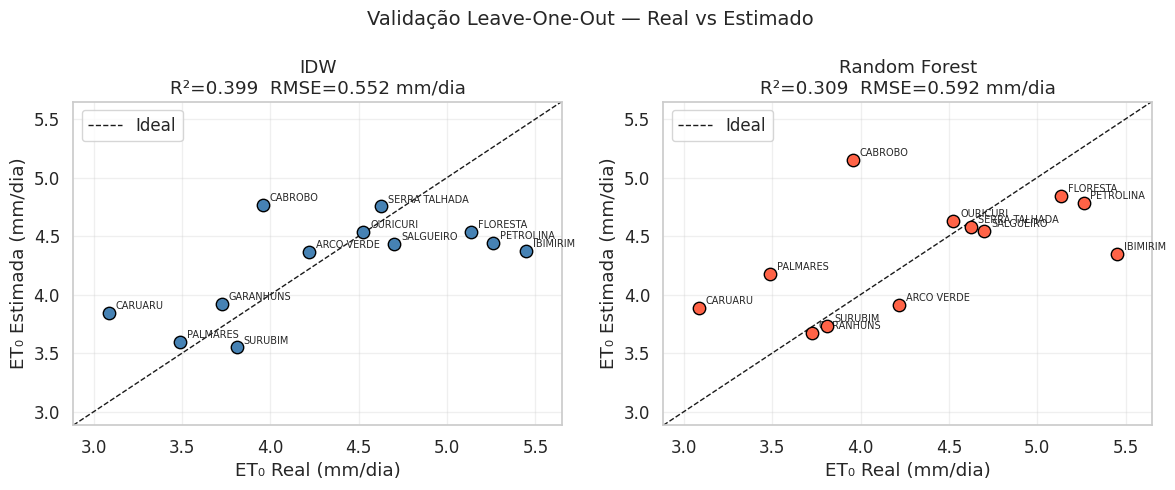

In [ ]:
# PARTE 5: Validação — Leave-One-Out Cross Validation

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

n = len(estacoes)
pred_idw = []
pred_rf  = []
reais    = []

print("Validação Leave-One-Out:\n")
print(f"{'Estação':<15} {'Real':>6} {'IDW':>6} {'RF':>6} {'Err_IDW':>8} {'Err_RF':>8}")
print("-" * 55)

for i in range(n):
    # Remove estação i
    mask = np.ones(n, dtype=bool)
    mask[i] = False

    coords_train = coords[mask]
    et0_train    = et0_vals[mask]
    X_train      = estacoes[['lon','lat','alt']].values[mask]

    ponto_test   = coords[i].reshape(1, -1)
    et0_real     = et0_vals[i]
    X_test       = estacoes[['lon','lat','alt']].values[i].reshape(1, -1)

    # IDW
    p_idw = idw(coords_train, et0_train, ponto_test)[0]

    # Random Forest
    rf_loo = RandomForestRegressor(n_estimators=200, random_state=42)
    rf_loo.fit(X_train, et0_train)
    p_rf = rf_loo.predict(X_test)[0]

    pred_idw.append(p_idw)
    pred_rf.append(p_rf)
    reais.append(et0_real)

    nome = estacoes['nome'].iloc[i]
    print(f"{nome:<15} {et0_real:>6.2f} {p_idw:>6.2f} {p_rf:>6.2f} "
          f"{abs(et0_real-p_idw):>8.2f} {abs(et0_real-p_rf):>8.2f}")

reais    = np.array(reais)
pred_idw = np.array(pred_idw)
pred_rf  = np.array(pred_rf)

# Métricas
print("\n--- Métricas de Validação ---")
for nome_m, pred in [("IDW", pred_idw), ("Random Forest", pred_rf)]:
    rmse = np.sqrt(mean_squared_error(reais, pred))
    mae  = mean_absolute_error(reais, pred)
    r2   = r2_score(reais, pred)
    print(f"\n{nome_m}:")
    print(f"  RMSE: {rmse:.4f} mm/dia")
    print(f"  MAE:  {mae:.4f} mm/dia")
    print(f"  R²:   {r2:.4f}")

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, titulo, cor in zip(
    axes,
    [pred_idw, pred_rf],
    ['IDW', 'Random Forest'],
    ['steelblue', 'tomato']
):
    ax.scatter(reais, pred, color=cor, s=80, edgecolors='black', zorder=5)
    lim = [min(reais.min(), pred.min()) - 0.2,
           max(reais.max(), pred.max()) + 0.2]
    ax.plot(lim, lim, 'k--', linewidth=1, label='Ideal')
    for i, nome in enumerate(estacoes['nome']):
        ax.annotate(nome, (reais[i], pred[i]),
                    textcoords='offset points', xytext=(5, 3), fontsize=7)
    r2 = r2_score(reais, pred)
    rmse = np.sqrt(mean_squared_error(reais, pred))
    ax.set_xlabel('ET₀ Real (mm/dia)')
    ax.set_ylabel('ET₀ Estimada (mm/dia)')
    ax.set_title(f'{titulo}\nR²={r2:.3f}  RMSE={rmse:.3f} mm/dia')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Validação Leave-One-Out — Real vs Estimado', fontsize=14)
plt.tight_layout()
plt.savefig('grafico8_validacao.png', dpi=150)
plt.show()